# Step 3: Visualization - The Risk Map
## Creating heat maps and bleaching risk visualizations

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.colors import LinearSegmentedColormap
import folium
from folium import plugins
import tensorflow as tf
from tensorflow import keras
from scipy.spatial import Delaunay
import warnings
warnings.filterwarnings('ignore')

## Load the trained model

In [2]:
# Load the best trained model
model = keras.models.load_model('pinn_model_best.h5', compile=False)
print("Model loaded successfully")
print(f"Model input shape: {model.input_shape}")
print(f"Model output shape: {model.output_shape}")

Model loaded successfully
Model input shape: (None, 3)
Model output shape: (None, 1)


## Load scalers and sensor info

In [3]:
# Load scalers
with open('scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

scaler_lat = scalers['scaler_lat']
scaler_lon = scalers['scaler_lon']
scaler_time = scalers['scaler_time']
scaler_temp = scalers['scaler_temp']

print("Scalers loaded")

Scalers loaded


In [4]:
# Load sensor information
with open('sensor_info.pkl', 'rb') as f:
    sensor_info = pickle.load(f)

sensor_coords = sensor_info['sensor_coords']
time_range = sensor_info['time_range']
temp_range = sensor_info['temp_range']

print("Sensor Information:")
print(f"  Number of sensors: {len(sensor_coords)}")
print(f"  Time range: {time_range[0]} to {time_range[1]}")
print(f"  Temperature range: {temp_range[0]:.2f}°C to {temp_range[1]:.2f}°C")
print(f"\nSensor coordinates:")
for i, (lat, lon) in enumerate(sensor_coords, 1):
    print(f"  Sensor {i}: ({lat}, {lon})")

Sensor Information:
  Number of sensors: 15
  Time range: 2015-03-01 12:00:00+00:00 to 2026-02-23 12:00:00+00:00
  Temperature range: 25.23°C to 32.67°C

Sensor coordinates:
  Sensor 1: (6.13, 80.075)
  Sensor 2: (6.12, 80.08)
  Sensor 3: (6.12, 80.07)
  Sensor 4: (6.18, 81.475)
  Sensor 5: (6.17, 81.48)
  Sensor 6: (6.17, 81.47)
  Sensor 7: (7.93, 81.575)
  Sensor 8: (7.92, 81.58)
  Sensor 9: (7.92, 81.57)
  Sensor 10: (8.38, 79.725)
  Sensor 11: (8.37, 79.73)
  Sensor 12: (8.37, 79.72)
  Sensor 13: (8.73, 81.175)
  Sensor 14: (8.72, 81.18)
  Sensor 15: (8.72, 81.17)


## Define bleaching risk thresholds

In [5]:
# Coral bleaching temperature thresholds (°C)
# These are typical values for coral reefs
TEMP_HEALTHY = 28.0      # Green: Below this is healthy
TEMP_WARNING = 30.0      # Yellow: Warning zone
TEMP_DANGER = 31.0       # Red: High risk above this

print("Bleaching Risk Thresholds:")
print(f"  🟢 Healthy:  < {TEMP_HEALTHY}°C")
print(f"  🟡 Warning:  {TEMP_HEALTHY}°C - {TEMP_WARNING}°C")
print(f"  🔴 Danger:   > {TEMP_WARNING}°C")

Bleaching Risk Thresholds:
  🟢 Healthy:  < 28.0°C
  🟡 Warning:  28.0°C - 30.0°C
  🔴 Danger:   > 30.0°C


In [6]:
def temperature_to_risk(temp):
    """
    Convert temperature to risk level and color
    
    Args:
        temp: Temperature in Celsius
    
    Returns:
        risk_level: 0 (healthy), 1 (warning), 2 (danger)
        color: RGB color for visualization
    """
    if temp < TEMP_HEALTHY:
        return 0, 'green'
    elif temp < TEMP_WARNING:
        return 1, 'yellow'
    else:
        return 2, 'red'

def get_risk_score(temp):
    """
    Convert temperature to continuous risk score (0-1)
    """
    if temp < TEMP_HEALTHY:
        return (temp - 26.0) / (TEMP_HEALTHY - 26.0) * 0.33
    elif temp < TEMP_WARNING:
        return 0.33 + (temp - TEMP_HEALTHY) / (TEMP_WARNING - TEMP_HEALTHY) * 0.33
    else:
        return 0.66 + min((temp - TEMP_WARNING) / 2.0, 1.0) * 0.34

print("Risk conversion functions defined")

Risk conversion functions defined


## Generate prediction grids (one per place triangle)

In [7]:
from scipy.spatial import Delaunay

# Group sensor_coords into per-place triangles (3 consecutive = 1 place)
place_triangles = [
    sensor_coords[i*3 : i*3 + 3]
    for i in range(len(sensor_coords) // 3)
]

def point_in_triangle_delaunay(p_lat, p_lon, triangle):
    """Check if point (lat, lon) is inside a triangle using Delaunay."""
    pts = np.array([[lat, lon] for lat, lon in triangle])
    hull = Delaunay(pts)
    return hull.find_simplex(np.array([[p_lat, p_lon]])) >= 0

print(f"Number of monitoring places: {len(place_triangles)}")
print("Triangle point check function defined (Delaunay-based)")


Number of monitoring places: 5
Triangle point check function defined (Delaunay-based)


In [8]:
# Create a dense grid inside EACH place triangle, then combine
grid_resolution = 50   # points per side per triangle

lats_inside = []
lons_inside = []
place_labels = []   # which place each point belongs to

for p_idx, triangle in enumerate(place_triangles):
    t_lats = [c[0] for c in triangle]
    t_lons = [c[1] for c in triangle]
    lat_min, lat_max = min(t_lats) - 0.001, max(t_lats) + 0.001
    lon_min, lon_max = min(t_lons) - 0.001, max(t_lons) + 0.001

    lat_grid = np.linspace(lat_min, lat_max, grid_resolution)
    lon_grid = np.linspace(lon_min, lon_max, grid_resolution)
    lat_mesh, lon_mesh = np.meshgrid(lat_grid, lon_grid)

    for i in range(grid_resolution):
        for j in range(grid_resolution):
            if point_in_triangle_delaunay(lat_mesh[i,j], lon_mesh[i,j], triangle):
                lats_inside.append(lat_mesh[i, j])
                lons_inside.append(lon_mesh[i, j])
                place_labels.append(p_idx)

print(f"Grid resolution per triangle: {grid_resolution}x{grid_resolution}")
print(f"Total grid points inside all triangles: {len(lats_inside)}")


Grid resolution per triangle: 50x50
Total grid points inside all triangles: 4000


In [9]:
# Grid points are now collected in the cell above (per-place grids)
print(f"Total points inside all triangles: {len(lats_inside)}")

Total points inside all triangles: 4000


## Predict temperature for all grid points

In [10]:
# Select a specific time point for visualization (middle of the dataset)
time_point_days = scaler_time.data_max_[0] / 2  # Middle time point

print(f"Generating predictions for time: {time_point_days:.1f} days from start")

Generating predictions for time: 2006.0 days from start


In [11]:
# Prepare input for all grid points at the selected time
n_points = len(lats_inside)
grid_inputs = np.zeros((n_points, 3))

# Normalize inputs
grid_inputs[:, 0] = scaler_lat.transform(np.array(lats_inside).reshape(-1, 1)).flatten()
grid_inputs[:, 1] = scaler_lon.transform(np.array(lons_inside).reshape(-1, 1)).flatten()
grid_inputs[:, 2] = scaler_time.transform(np.array([[time_point_days]] * n_points)).flatten()

print(f"Input shape for prediction: {grid_inputs.shape}")

Input shape for prediction: (4000, 3)


In [12]:
# Make predictions
print("Predicting temperatures for grid points...")
predictions_norm = model.predict(grid_inputs, verbose=0)
predictions = scaler_temp.inverse_transform(predictions_norm).flatten()

print(f"Predictions complete!")
print(f"Temperature range: {predictions.min():.2f}°C to {predictions.max():.2f}°C")

Predicting temperatures for grid points...
Predictions complete!
Temperature range: 28.55°C to 29.20°C


## Convert temperatures to risk scores

In [13]:
# Calculate risk scores
risk_scores = np.array([get_risk_score(temp) for temp in predictions])

# Count risk levels
healthy_count = np.sum(predictions < TEMP_HEALTHY)
warning_count = np.sum((predictions >= TEMP_HEALTHY) & (predictions < TEMP_WARNING))
danger_count = np.sum(predictions >= TEMP_WARNING)

print("Risk Distribution:")
print(f"  🟢 Healthy: {healthy_count} points ({100*healthy_count/len(predictions):.1f}%)")
print(f"  🟡 Warning: {warning_count} points ({100*warning_count/len(predictions):.1f}%)")
print(f"  🔴 Danger:  {danger_count} points ({100*danger_count/len(predictions):.1f}%)")

Risk Distribution:
  🟢 Healthy: 0 points (0.0%)
  🟡 Warning: 4000 points (100.0%)
  🔴 Danger:  0 points (0.0%)


## Matplotlib visualization

In [14]:
# Create custom colormap (green -> yellow -> red)
# Adjusted to keep warning zone (0.33-0.66) more yellow
colors = ['green', 'yellow', 'yellow', 'orange', 'red']
color_positions = [0.0, 0.33, 0.6, 0.75, 1.0]
n_bins = 100
cmap = LinearSegmentedColormap.from_list('risk', list(zip(color_positions, colors)))

print("Custom colormap created (adjusted for accurate risk visualization)")

Custom colormap created (adjusted for accurate risk visualization)


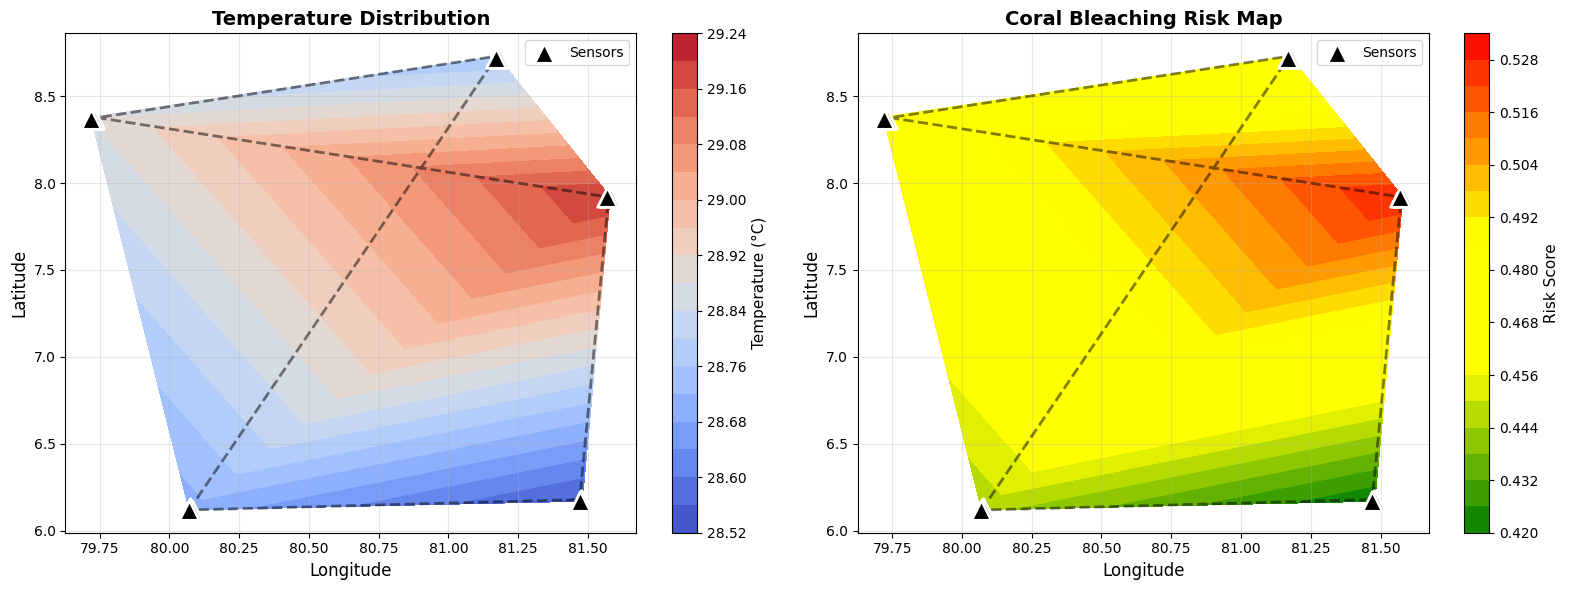

Heat map saved as 'heatmap_visualization.png'


In [15]:
# Plot temperature heat map
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature map
ax1 = axes[0]
sc1 = ax1.tricontourf(lons_inside, lats_inside, predictions, 
                      levels=20, cmap='coolwarm')
ax1.scatter([c[1] for c in sensor_coords], [c[0] for c in sensor_coords],
           c='black', s=200, marker='^', edgecolors='white', linewidths=2,
           label='Sensors', zorder=5)
ax1.plot([c[1] for c in sensor_coords] + [sensor_coords[0][1]], 
        [c[0] for c in sensor_coords] + [sensor_coords[0][0]],
        'k--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title('Temperature Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Temperature (°C)', fontsize=11)

# Risk map
ax2 = axes[1]
sc2 = ax2.tricontourf(lons_inside, lats_inside, risk_scores,
                      levels=20, cmap=cmap)
ax2.scatter([c[1] for c in sensor_coords], [c[0] for c in sensor_coords],
           c='black', s=200, marker='^', edgecolors='white', linewidths=2,
           label='Sensors', zorder=5)
ax2.plot([c[1] for c in sensor_coords] + [sensor_coords[0][1]], 
        [c[0] for c in sensor_coords] + [sensor_coords[0][0]],
        'k--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Coral Bleaching Risk Map', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Risk Score', fontsize=11)

plt.tight_layout()
plt.savefig('heatmap_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heat map saved as 'heatmap_visualization.png'")

## Folium interactive map

In [16]:
# Map centered on Sri Lanka (all 5 places)
center_lat = np.mean([c[0] for c in sensor_coords])
center_lon = np.mean([c[1] for c in sensor_coords])
print(f"Map center: ({center_lat:.4f}, {center_lon:.4f})")


Map center: (7.4633, 80.8050)


In [17]:
# Create base map zoomed to show all of Sri Lanka's monitoring areas
m = folium.Map(
    location=[float(center_lat), float(center_lon)],
    zoom_start=7,
    tiles='OpenStreetMap'
)
print("Folium map created")


Folium map created


In [18]:
# Draw one triangle boundary per place and add sensor markers
place_names = ["Hikkaduwa", "South East", "Passikudha", "Kalpitiya", "Trinco"]
colors_place = ["blue", "green", "purple", "orange", "red"]

for p_idx, (triangle, pname, pcolor) in enumerate(
        zip(place_triangles, place_names, colors_place)):
    # Triangle boundary (close the loop)
    tri_coords = [[float(lat), float(lon)] for lat, lon in triangle]
    tri_coords.append(tri_coords[0])
    folium.PolyLine(
        tri_coords,
        color=pcolor,
        weight=2,
        opacity=0.8,
        popup=f"{pname} monitoring area"
    ).add_to(m)

    # Sensor markers for this triangle
    for s_idx, (lat, lon) in enumerate(triangle):
        folium.Marker(
            location=[float(lat), float(lon)],
            popup=f"{pname} - Sensor {s_idx+1}<br>Lat: {lat}<br>Lon: {lon}",
            icon=folium.Icon(color=pcolor, icon="info-sign"),
            tooltip=f"{pname} S{s_idx+1}"
        ).add_to(m)

print("Sensor markers and triangle boundaries added for all 5 places")


Sensor markers and triangle boundaries added for all 5 places


In [19]:
# Draw one triangle boundary per place and add sensor markers
place_names = ["Hikkaduwa", "South East", "Passikudha", "Kalpitiya", "Trinco"]
colors_place = ["blue", "green", "purple", "orange", "red"]

for p_idx, (triangle, pname, pcolor) in enumerate(
        zip(place_triangles, place_names, colors_place)):
    # Triangle boundary (close the loop)
    tri_coords = [[float(lat), float(lon)] for lat, lon in triangle]
    tri_coords.append(tri_coords[0])
    folium.PolyLine(
        tri_coords,
        color=pcolor,
        weight=2,
        opacity=0.8,
        popup=f"{pname} monitoring area"
    ).add_to(m)

    # Sensor markers for this triangle
    for s_idx, (lat, lon) in enumerate(triangle):
        folium.Marker(
            location=[float(lat), float(lon)],
            popup=f"{pname} - Sensor {s_idx+1}<br>Lat: {lat}<br>Lon: {lon}",
            icon=folium.Icon(color=pcolor, icon="info-sign"),
            tooltip=f"{pname} S{s_idx+1}"
        ).add_to(m)

print("Sensor markers and triangle boundaries added for all 5 places")


Sensor markers and triangle boundaries added for all 5 places


In [20]:
# Create heat map data (convert numpy types to Python native types for JSON serialization)
heat_data = [[float(lat), float(lon), float(risk)] for lat, lon, risk in zip(lats_inside, lons_inside, risk_scores)]

# Add heat map layer with adjusted gradient
# Keep warning zone (0.33-0.66) predominantly yellow
plugins.HeatMap(
    heat_data,
    min_opacity=0.3,
    max_opacity=0.8,
    radius=15,
    blur=20,
    gradient={
        0.0: 'green',
        0.33: 'yellow',
        0.6: 'yellow',      # Keep warning zone yellow longer
        0.7: 'orange',      # Start orange closer to danger zone
        1.0: 'red'
    }
).add_to(m)

print("Heat map layer added (gradient adjusted for accurate risk zones)")

Heat map layer added (gradient adjusted for accurate risk zones)


In [21]:
# Add risk legend
legend_html = '''
<div style="position: fixed; 
            top: 10px; right: 10px; width: 200px; height: 140px; 
            background-color: white; border:2px solid grey; z-index:9999; 
            font-size:14px; padding: 10px">
    <p style="margin:0; font-weight:bold; text-align:center;">Bleaching Risk</p>
    <p style="margin:5px 0;">🟢 Healthy: < 28°C</p>
    <p style="margin:5px 0;">🟡 Warning: 28-30°C</p>
    <p style="margin:5px 0;">🔴 Danger: > 30°C</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

print("Legend added")

Legend added


In [22]:
# Save the map
m.save('coral_reef_risk_map.html')
print("Interactive map saved as 'coral_reef_risk_map.html'")
print("Open this file in a web browser to view the interactive map!")

Interactive map saved as 'coral_reef_risk_map.html'
Open this file in a web browser to view the interactive map!


## Create time series animation data

In [23]:
# Select multiple time points for animation
n_timepoints = 10
time_points = np.linspace(0, scaler_time.data_max_[0], n_timepoints)

print(f"Generating predictions for {n_timepoints} time points...")
print(f"Time range: 0 to {scaler_time.data_max_[0]:.1f} days")

Generating predictions for 10 time points...
Time range: 0 to 4012.0 days


In [24]:
# Generate predictions for each time point
all_predictions = []

for t_idx, t in enumerate(time_points):
    # Prepare inputs
    grid_inputs_t = grid_inputs.copy()
    grid_inputs_t[:, 2] = scaler_time.transform(np.array([[t]] * n_points)).flatten()
    
    # Predict
    preds_norm = model.predict(grid_inputs_t, verbose=0)
    preds = scaler_temp.inverse_transform(preds_norm).flatten()
    all_predictions.append(preds)
    
    print(f"  Time {t_idx+1}/{n_timepoints}: {t:.1f} days - Temp range: {preds.min():.2f}-{preds.max():.2f}°C")

all_predictions = np.array(all_predictions)
print(f"\nPrediction array shape: {all_predictions.shape}")

  Time 1/10: 0.0 days - Temp range: 28.78-29.41°C
  Time 2/10: 445.8 days - Temp range: 28.55-29.09°C
  Time 3/10: 891.6 days - Temp range: 28.15-28.86°C
  Time 4/10: 1337.3 days - Temp range: 28.15-28.85°C
  Time 5/10: 1783.1 days - Temp range: 28.69-29.23°C
  Time 6/10: 2228.9 days - Temp range: 28.48-29.17°C
  Time 7/10: 2674.7 days - Temp range: 28.01-28.97°C
  Time 8/10: 3120.4 days - Temp range: 28.76-29.28°C
  Time 9/10: 3566.2 days - Temp range: 28.71-29.30°C
  Time 10/10: 4012.0 days - Temp range: 27.13-28.21°C

Prediction array shape: (10, 4000)


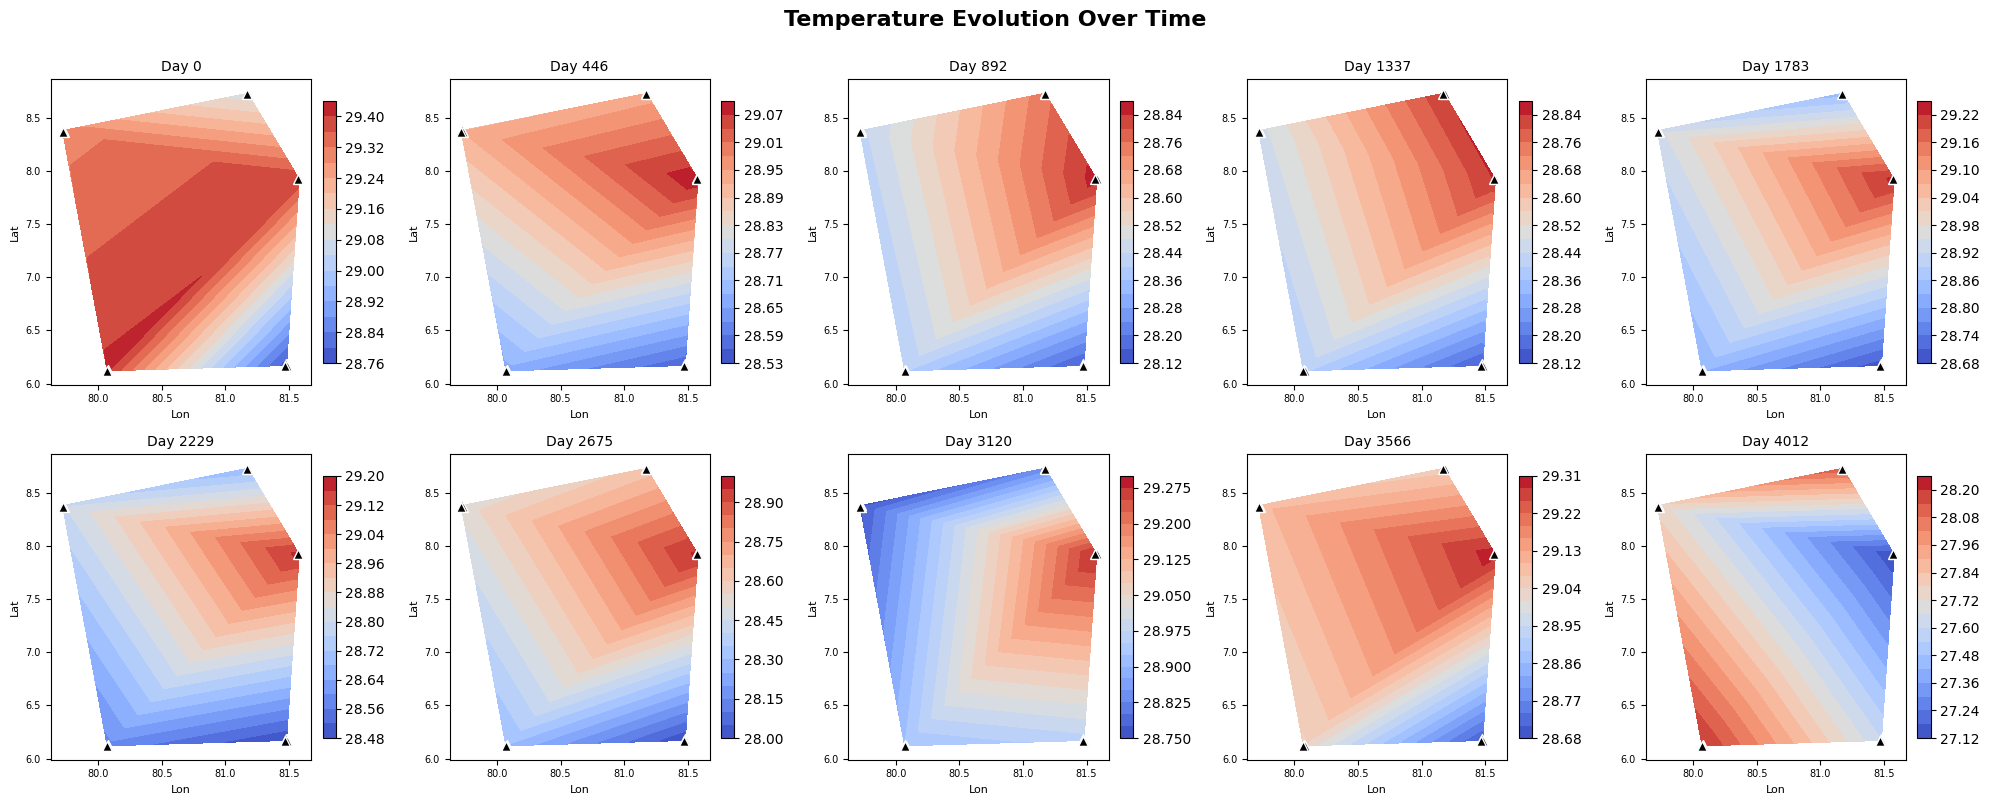

Temperature evolution plot saved as 'temperature_evolution.png'


In [25]:
# Plot temperature evolution over time
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, (t, preds) in enumerate(zip(time_points, all_predictions)):
    ax = axes[idx]
    sc = ax.tricontourf(lons_inside, lats_inside, preds, levels=20, cmap='coolwarm')
    ax.scatter([c[1] for c in sensor_coords], [c[0] for c in sensor_coords],
               c='black', s=50, marker='^', edgecolors='white', linewidths=1)
    ax.set_title(f'Day {t:.0f}', fontsize=10)
    ax.set_xlabel('Lon', fontsize=8)
    ax.set_ylabel('Lat', fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Temperature Evolution Over Time', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('temperature_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Temperature evolution plot saved as 'temperature_evolution.png'")

## Summary statistics

In [26]:
avg_temp = np.mean(all_predictions)
max_temp = np.max(all_predictions)
min_temp = np.min(all_predictions)
std_temp = np.std(all_predictions)

print("\n" + "="*60)
print("CORAL REEF DIGITAL TWIN - SUMMARY STATISTICS")
print("="*60)
print(f"Monitoring Area:")
print(f"  Number of places  : {len(place_triangles)}")
print(f"  Sensors per place : 3  (triangle)")
print(f"  Total sensors     : {len(sensor_coords)}")
print(f"  Grid resolution   : {grid_resolution}x{grid_resolution} per triangle")
print(f"  Total grid points : {len(lats_inside)}")
print(f"\nTemperature Statistics (across all time points):")
print(f"  Average:  {avg_temp:.2f}C")
print(f"  Min:      {min_temp:.2f}C")
print(f"  Max:      {max_temp:.2f}C")
print(f"  Std Dev:  {std_temp:.2f}C")
print(f"\nCurrent Risk Assessment (snapshot):")
print(f"  Healthy: {healthy_count} points ({100*healthy_count/len(predictions):.1f}%)")
print(f"  Warning: {warning_count} points ({100*warning_count/len(predictions):.1f}%)")
print(f"  Danger:  {danger_count} points ({100*danger_count/len(predictions):.1f}%)")
print("="*60)



CORAL REEF DIGITAL TWIN - SUMMARY STATISTICS
Monitoring Area:
  Number of places  : 5
  Sensors per place : 3  (triangle)
  Total sensors     : 15
  Grid resolution   : 50x50 per triangle
  Total grid points : 4000

Temperature Statistics (across all time points):
  Average:  28.70C
  Min:      27.13C
  Max:      29.41C
  Std Dev:  0.46C

Current Risk Assessment (snapshot):
  Healthy: 0 points (0.0%)
  Danger:  0 points (0.0%)


## Display the map in notebook (if running in Jupyter)

In [27]:
# Display the map inline
m

## Export data for external use

In [28]:
# Create DataFrame with predictions
results_df = pd.DataFrame({
    'latitude': lats_inside,
    'longitude': lons_inside,
    'temperature': predictions,
    'risk_score': risk_scores,
    'risk_level': [temperature_to_risk(t)[0] for t in predictions]
})

results_df.to_csv('prediction_results.csv', index=False)
print("Prediction results saved as 'prediction_results.csv'")
results_df.head(10)

Prediction results saved as 'prediction_results.csv'


,latitude,longitude,temperature,risk_score,risk_level
0,6.120224,80.070224,28.702747,0.445953,1
1,6.120224,80.070469,28.702660,0.445939,1
2,6.120469,80.070469,28.702774,0.445958,1
3,6.120714,80.070469,28.702885,0.445976,1
4,6.120224,80.070714,28.702572,0.445924,1
5,6.120469,80.070714,28.702686,0.445943,1
6,6.120714,80.070714,28.702799,0.445962,1
7,6.120959,80.070714,28.702911,0.445980,1
8,6.121204,80.070714,28.703024,0.445999,1
9,6.120224,80.070959,28.702488,0.445911,1


In [29]:
print("\n" + "="*60)
print("VISUALIZATION COMPLETE!")
print("="*60)
print("\nYour Coral Reef Digital Twin is ready!")
print("\nNext steps:")
print("  1. Open 'coral_reef_risk_map.html' to view the interactive map")
print("  2. View the PNG images for static visualizations")
print("  3. Use 'prediction_results.csv' for further analysis")
print("  4. Scale to more sensors by modifying the sensor coordinates")
print("="*60)


VISUALIZATION COMPLETE!

Your Coral Reef Digital Twin is ready!

Next steps:
  1. Open 'coral_reef_risk_map.html' to view the interactive map
  2. View the PNG images for static visualizations
  3. Use 'prediction_results.csv' for further analysis
  4. Scale to more sensors by modifying the sensor coordinates
